# CD-A vs Greedy-CD-A on ER Graphs (no-epoch)

Compare the random T-step coordinate descent (`dag_coordinate_descent_l0`)
against the greedy T-step coordinate descent (`dag_greedy_A`) on random ER
graphs. Both solvers are the no-epoch / per-step variants.

Metrics: SHD, CPDAG-SHD, MEC match, runtime.

In [1]:
# 1) Environment and imports
import os
import sys
import time
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

print('Python   :', sys.version.split()[0])
print('Repo root:', repo_root)

from MEC import is_in_markov_equiv_class, get_skeleton, find_v_structures
from synthetic_dataset import SyntheticDataset
from coordinate_descent.coordinate0 import dag_coordinate_descent_l0 as cd_noepoch_fit
from coordinate_descent.cd_greedy_A import dag_greedy_A as greedy_cd_noepoch_fit

try:
    _tb = os.path.join(repo_root, 'toolbox')
    if _tb not in sys.path:
        sys.path.append(_tb)
    from cdt.metrics import SHD_CPDAG as _SHD_CPDAG
    HAS_CPDAG_SHD = True
except Exception as _e:
    _SHD_CPDAG = None
    HAS_CPDAG_SHD = False
    print('CPDAG-SHD backend unavailable (fallback):', _e)

print('CD-A      : OK')
print('Greedy-CD : OK')

Python   : 3.12.3
Repo root: c:\Users\super\DAG
c:\Users\super\DAG\experiments\notebooks\test


No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.


CD-A      : OK
Greedy-CD : OK


In [2]:
# 2) Helpers
def weight_to_binary_adj(W: np.ndarray, threshold: float = 0.05) -> np.ndarray:
    G = (np.abs(W) > threshold).astype(int)
    np.fill_diagonal(G, 0)
    return G


def cpdag_shd_score(G_true: np.ndarray, G_est: np.ndarray) -> float:
    if HAS_CPDAG_SHD:
        try:
            return float(_SHD_CPDAG(G_true.astype(int), G_est.astype(int)))
        except Exception:
            pass
    skel_true = get_skeleton(G_true)
    skel_est = get_skeleton(G_est)
    skel_diff = int(np.sum(np.abs(skel_true - skel_est)) // 2)
    v_diff = len(find_v_structures(G_true).symmetric_difference(find_v_structures(G_est)))
    return float(skel_diff + v_diff)


def shd_score(G_true: np.ndarray, G_est: np.ndarray) -> float:
    G_true = np.asarray(G_true, dtype=int)
    G_est = np.asarray(G_est, dtype=int)
    d, dist = G_true.shape[0], 0
    for i in range(d):
        for j in range(i + 1, d):
            if G_true[i, j] != G_est[i, j] or G_true[j, i] != G_est[j, i]:
                dist += 1
    return float(dist)


def make_row(d, n, trial_id, seed, alg, runtime_sec, G_true, G_est, actual_steps=None):
    mec = int(is_in_markov_equiv_class(G_true, G_est))
    shd = shd_score(G_true, G_est)
    cshd = cpdag_shd_score(G_true, G_est)
    row = {
        'd': d,
        'n_samples': n,
        'trial_id': trial_id,
        'seed': seed,
        'algorithm': alg,
        'mec_match': mec,
        'shd': shd,
        'cpdag_shd': cshd,
        'n_edges_true': int(G_true.sum()),
        'n_edges_est': int(G_est.sum()),
        'runtime_sec': float(runtime_sec),
    }
    if actual_steps is not None:
        row['actual_steps'] = int(actual_steps)
    return row


def summarize(df: pd.DataFrame) -> pd.DataFrame:
    if len(df) == 0:
        return pd.DataFrame()
    agg_dict = dict(
        mec_match_mean=('mec_match', 'mean'),
        shd_mean=('shd', 'mean'),
        cpdag_shd_mean=('cpdag_shd', 'mean'),
        runtime_sec_mean=('runtime_sec', 'mean'),
        trials=('trial_id', 'count'),
    )
    if 'actual_steps' in df.columns:
        agg_dict['actual_steps_mean'] = ('actual_steps', 'mean')
        agg_dict['actual_steps_min'] = ('actual_steps', 'min')
        agg_dict['actual_steps_max'] = ('actual_steps', 'max')
    return (
        df.groupby(['algorithm', 'd', 'n_samples'], as_index=False)
        .agg(**agg_dict)
    )


def iter_trials(cfg: dict):
    rng = np.random.default_rng(cfg['seed'])
    for d in cfg['d_list']:
        for n in cfg['n_list']:
            seeds = rng.integers(0, 10**9, size=cfg['trials'])
            for trial_idx, seed in enumerate(seeds, start=1):
                dataset = SyntheticDataset(
                    n=n,
                    d=d,
                    graph_type='ER',
                    degree=cfg['degree'],
                    noise_type=cfg['noise_type'],
                    B_scale=cfg['b_scale'],
                    seed=int(seed),
                )
                X = dataset.X
                S = X.T @ X / X.shape[0]
                G_true = weight_to_binary_adj(dataset.B, threshold=0.0)
                yield d, n, trial_idx, int(seed), X, S, G_true


print('Helpers ready.')


Helpers ready.


In [3]:
# 3) Config
CFG = {
    'trials': 5,
    'seed': 42,
    'd_list': [20, 30],
    'n_list': [20000],
    'degree': 2.0,
    'noise_type': 'gaussian_nv',
    'b_scale': 1.0,
    'threshold': 0.05,
    'lambda_l0': 0.2,
    # Random CD needs many random draws to cover all coordinates;
    # greedy CD converges in O(d^2) accepted updates and then implicitly stops.
    'T_cd_A': 100000,
    'T_greedy': 50000,
    'out_dir': os.path.join(repo_root, 'experiments', 'results'),
    'tag': 'er_cd_A_vs_greedy_cd_A_noepoch',
    # --- Early-stopping config ---
    # Set early_stop=True to enable explicit relative-improvement stopping.
    # check_every: check interval in steps (None → d*(d+1)//2)
    # tol: min relative improvement to reset patience counter
    # patience: consecutive below-tol checks before stopping
    # min_steps: warm-up steps before patience kicks in (None → check_every*10)
    'early_stop': True,
    'es_check_every': None,   # None → use d*(d+1)//2
    'es_tol': 1e-4,
    'es_patience': 10,
    'es_min_steps': None,     # None → use check_every*10
}
os.makedirs(CFG['out_dir'], exist_ok=True)

print('Config ready.')
print(f"  d_list      : {CFG['d_list']}")
print(f"  n_list      : {CFG['n_list']}")
print(f"  trials      : {CFG['trials']}")
print(f"  lambda      : {CFG['lambda_l0']}")
print(f"  T cd_A      : {CFG['T_cd_A']}")
print(f"  T greedy    : {CFG['T_greedy']}")
print(f"  early_stop  : {CFG['early_stop']}")
print(f"  es_tol      : {CFG['es_tol']}  patience={CFG['es_patience']}")


Config ready.
  d_list      : [20, 30]
  n_list      : [20000]
  trials      : 5
  lambda      : 0.2
  T cd_A      : 100000
  T greedy    : 50000
  early_stop  : True
  es_tol      : 0.0001  patience=10


In [4]:
# 4) Run both solvers on the same trials
rows = []
skip_logs = []

for d, n, trial_id, seed, X, S, G_true in iter_trials(CFG):
    # ---- cd_A (random no-epoch) ----
    alg = 'cd_A_noepoch'
    try:
        t0 = time.perf_counter()
        result = cd_noepoch_fit(
            S=S,
            T=CFG['T_cd_A'],
            seed=seed,
            threshold=CFG['threshold'],
            lambda_l0=CFG['lambda_l0'],
            early_stop=CFG['early_stop'],
            check_every=CFG['es_check_every'],
            tol=CFG['es_tol'],
            patience=CFG['es_patience'],
            min_steps=CFG['es_min_steps'],
            return_history=CFG['early_stop'],  # need history to get actual_steps
        )
        rt = time.perf_counter() - t0
        if CFG['early_stop']:
            _, G_est, _, history_cd = result
            actual_steps = len(history_cd)
        else:
            _, G_est, _ = result
            actual_steps = None
        row = make_row(d, n, trial_id, seed, alg, rt, G_true, G_est, actual_steps=actual_steps)
        rows.append(row)
        steps_str = f'  steps={actual_steps}' if actual_steps is not None else ''
        print(
            f'[{alg}] d={d} n={n} trial={trial_id}  '
            f'mec={row["mec_match"]}  shd={row["shd"]:.0f}  '
            f'cpdag_shd={row["cpdag_shd"]:.0f}  rt={rt:.3f}s{steps_str}'
        )
    except Exception as e:
        skip_logs.append({'algorithm': alg, 'd': d, 'n_samples': n, 'trial_id': trial_id, 'reason': str(e)})
        print(f'[SKIP] {alg} d={d} n={n} trial={trial_id}: {e}')

    # ---- greedy_cd_A (greedy no-epoch) ----
    alg = 'greedy_cd_A_noepoch'
    try:
        t0 = time.perf_counter()
        result = greedy_cd_noepoch_fit(
            S=S,
            T=CFG['T_greedy'],
            seed=seed,
            threshold=CFG['threshold'],
            lambda_l0=CFG['lambda_l0'],
            early_stop=CFG['early_stop'],
            check_every=CFG['es_check_every'],
            tol=CFG['es_tol'],
            patience=CFG['es_patience'],
            min_steps=CFG['es_min_steps'],
            return_history=CFG['early_stop'],  # need history to get actual_steps
        )
        rt = time.perf_counter() - t0
        if CFG['early_stop']:
            _, G_est, _, history_greedy = result
            actual_steps = len(history_greedy)
        else:
            _, G_est, _ = result
            actual_steps = None
        row = make_row(d, n, trial_id, seed, alg, rt, G_true, G_est, actual_steps=actual_steps)
        rows.append(row)
        steps_str = f'  steps={actual_steps}' if actual_steps is not None else ''
        print(
            f'[{alg}] d={d} n={n} trial={trial_id}  '
            f'mec={row["mec_match"]}  shd={row["shd"]:.0f}  '
            f'cpdag_shd={row["cpdag_shd"]:.0f}  rt={rt:.3f}s{steps_str}'
        )
    except Exception as e:
        skip_logs.append({'algorithm': alg, 'd': d, 'n_samples': n, 'trial_id': trial_id, 'reason': str(e)})
        print(f'[SKIP] {alg} d={d} n={n} trial={trial_id}: {e}')

df_trials = pd.DataFrame(rows)
df_summary = summarize(df_trials)

print('\nPer-(algorithm, d, n) summary:')
display(df_summary)


[cd_A_noepoch] d=20 n=20000 trial=1  mec=0  shd=16  cpdag_shd=15  rt=4.015s  steps=11970
[greedy_cd_A_noepoch] d=20 n=20000 trial=1  mec=0  shd=33  cpdag_shd=32  rt=31.650s  steps=3990
[cd_A_noepoch] d=20 n=20000 trial=2  mec=0  shd=10  cpdag_shd=8  rt=3.336s  steps=11550
[greedy_cd_A_noepoch] d=20 n=20000 trial=2  mec=0  shd=40  cpdag_shd=40  rt=34.832s  steps=3990
[cd_A_noepoch] d=20 n=20000 trial=3  mec=0  shd=7  cpdag_shd=5  rt=2.150s  steps=7140
[greedy_cd_A_noepoch] d=20 n=20000 trial=3  mec=0  shd=27  cpdag_shd=25  rt=35.002s  steps=3990
[cd_A_noepoch] d=20 n=20000 trial=4  mec=0  shd=10  cpdag_shd=13  rt=3.022s  steps=10920
[greedy_cd_A_noepoch] d=20 n=20000 trial=4  mec=0  shd=38  cpdag_shd=37  rt=35.973s  steps=3990
[cd_A_noepoch] d=20 n=20000 trial=5  mec=1  shd=1  cpdag_shd=0  rt=2.526s  steps=7560
[greedy_cd_A_noepoch] d=20 n=20000 trial=5  mec=0  shd=9  cpdag_shd=5  rt=11.287s  steps=1702
[cd_A_noepoch] d=30 n=20000 trial=1  mec=0  shd=14  cpdag_shd=12  rt=6.683s  steps=1

,algorithm,d,n_samples,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials,actual_steps_mean,actual_steps_min,actual_steps_max
0,cd_A_noepoch,20,20000,0.2,8.8,8.2,3.009806,5,9828.0,7140,11970
1,cd_A_noepoch,30,20000,0.0,20.6,19.6,10.155406,5,27900.0,18600,47895
2,greedy_cd_A_noepoch,20,20000,0.0,29.4,27.8,29.748863,5,3532.4,1702,3990
3,greedy_cd_A_noepoch,30,20000,0.0,47.0,44.8,163.125369,5,6179.6,1790,8835


=== Early-stop actual steps (mean ± std) ===
  cd_A_noepoch                    d= 20  steps: 9828 ± 2298  (budget=100000, stopped_early=True)
  cd_A_noepoch                    d= 30  steps: 27900 ± 11754  (budget=100000, stopped_early=True)
  greedy_cd_A_noepoch             d= 20  steps: 3532 ± 1023  (budget=50000, stopped_early=True)
  greedy_cd_A_noepoch             d= 30  steps: 6180 ± 2950  (budget=50000, stopped_early=True)


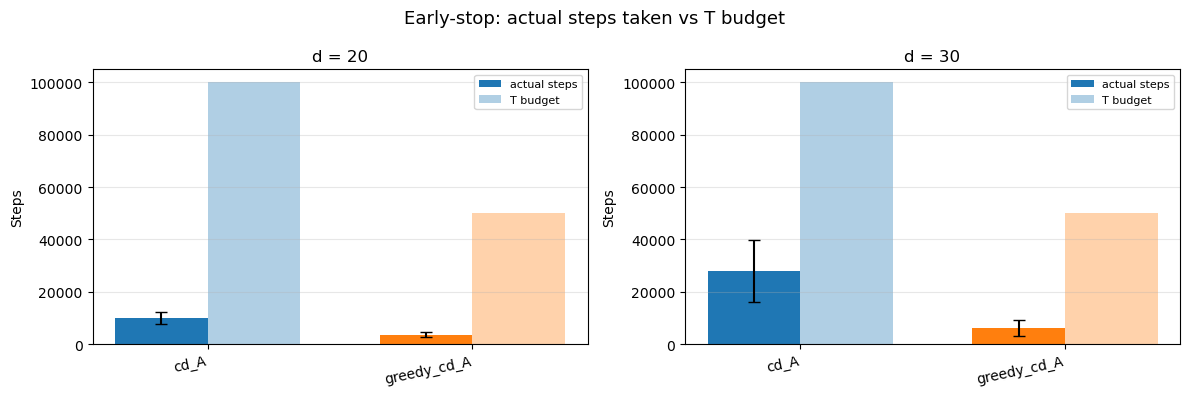

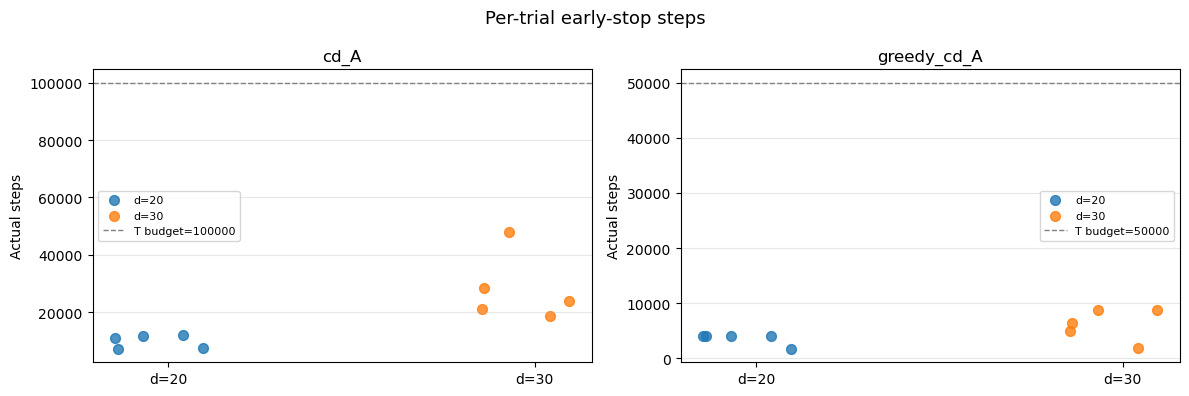

In [5]:
# 4b) Early-stop step comparison
# Shows where each algorithm actually stopped relative to the configured T budget.
if not CFG['early_stop'] or 'actual_steps' not in df_trials.columns:
    print('Early stopping was disabled — no step data to display.')
else:
    T_budget = {'cd_A_noepoch': CFG['T_cd_A'], 'greedy_cd_A_noepoch': CFG['T_greedy']}
    algs = sorted(df_trials['algorithm'].unique())
    d_vals = sorted(df_trials['d'].unique())

    print('=== Early-stop actual steps (mean ± std) ===')
    for alg in algs:
        sub = df_trials[df_trials['algorithm'] == alg]
        for d_val in d_vals:
            s = sub[sub['d'] == d_val]['actual_steps']
            T_bud = T_budget.get(alg, '?')
            print(
                f'  {alg:30s}  d={d_val:3d}  '
                f'steps: {s.mean():.0f} ± {s.std():.0f}  '
                f'(budget={T_bud}, '
                f'stopped_early={bool(s.mean() < T_bud)})'
            )

    # Bar chart: mean actual steps vs budget per algorithm × d
    fig, axes = plt.subplots(1, len(d_vals), figsize=(6 * len(d_vals), 4), sharey=False, squeeze=False)
    for ci, d_val in enumerate(d_vals):
        ax = axes[0][ci]
        sub_d = df_trials[df_trials['d'] == d_val]
        x = np.arange(len(algs))
        width = 0.35
        means = [sub_d[sub_d['algorithm'] == alg]['actual_steps'].mean() for alg in algs]
        stds  = [sub_d[sub_d['algorithm'] == alg]['actual_steps'].std() for alg in algs]
        budgets = [T_budget.get(alg, 0) for alg in algs]
        colors = ['C0', 'C1'][:len(algs)]

        ax.bar(x, means, width, yerr=stds, capsize=4, label='actual steps', color=colors)
        ax.bar(x + width, budgets, width, alpha=0.35, label='T budget', color=colors)

        ax.set_title(f'd = {d_val}')
        ax.set_xticks(x + width / 2)
        ax.set_xticklabels([a.replace('_noepoch', '') for a in algs], rotation=12, ha='right')
        ax.set_ylabel('Steps')
        ax.legend(fontsize=8)
        ax.grid(True, axis='y', alpha=0.3)

    fig.suptitle('Early-stop: actual steps taken vs T budget', fontsize=13)
    plt.tight_layout()
    plt.show()

    # Per-trial strip plot: actual steps, colored by d
    fig, axes = plt.subplots(1, len(algs), figsize=(6 * len(algs), 4), squeeze=False)
    for ci, alg in enumerate(algs):
        ax = axes[0][ci]
        sub = df_trials[df_trials['algorithm'] == alg]
        for d_idx, d_val in enumerate(d_vals):
            pts = sub[sub['d'] == d_val]['actual_steps'].values
            jitter = np.random.default_rng(0).uniform(-0.15, 0.15, size=len(pts))
            ax.scatter(np.full(len(pts), d_idx) + jitter, pts,
                       label=f'd={d_val}', color=f'C{d_idx}', s=50, alpha=0.8)
        T_bud = T_budget.get(alg, None)
        if T_bud is not None:
            ax.axhline(T_bud, color='gray', linestyle='--', linewidth=1, label=f'T budget={T_bud}')
        ax.set_title(alg.replace('_noepoch', ''))
        ax.set_xticks(range(len(d_vals)))
        ax.set_xticklabels([f'd={v}' for v in d_vals])
        ax.set_ylabel('Actual steps')
        ax.legend(fontsize=8)
        ax.grid(True, axis='y', alpha=0.3)

    fig.suptitle('Per-trial early-stop steps', fontsize=13)
    plt.tight_layout()
    plt.show()


In [6]:
# 5) Save results
if len(df_trials) == 0:
    print('WARNING: no results collected.')
else:
    ts_str = datetime.now().strftime('%Y%m%d_%H%M%S')
    trials_path = os.path.join(CFG['out_dir'], f"{CFG['tag']}_trials_{ts_str}.csv")
    summary_path = os.path.join(CFG['out_dir'], f"{CFG['tag']}_summary_{ts_str}.csv")
    latest_trials_path = os.path.join(CFG['out_dir'], f"{CFG['tag']}_trials.csv")
    latest_summary_path = os.path.join(CFG['out_dir'], f"{CFG['tag']}_summary.csv")

    df_trials.to_csv(trials_path, index=False)
    df_summary.to_csv(summary_path, index=False)
    df_trials.to_csv(latest_trials_path, index=False)
    df_summary.to_csv(latest_summary_path, index=False)

    print(f'Trials  saved to: {trials_path}')
    print(f'Summary saved to: {summary_path}')
    print(f'Rows: {len(df_trials)}  |  Skips: {len(skip_logs)}')

Trials  saved to: c:\Users\super\DAG\experiments\results\er_cd_A_vs_greedy_cd_A_noepoch_trials_20260408_190306.csv
Summary saved to: c:\Users\super\DAG\experiments\results\er_cd_A_vs_greedy_cd_A_noepoch_summary_20260408_190306.csv
Rows: 20  |  Skips: 0


In [7]:
# 6) Overall comparison
if len(df_trials) == 0:
    print('Run the previous cell first.')
else:
    df_overall = (
        df_trials
        .groupby('algorithm', as_index=False)
        .agg(
            mec_match_mean=('mec_match', 'mean'),
            shd_mean=('shd', 'mean'),
            cpdag_shd_mean=('cpdag_shd', 'mean'),
            runtime_sec_mean=('runtime_sec', 'mean'),
            trials=('trial_id', 'count'),
        )
        .sort_values('algorithm')
        .reset_index(drop=True)
    )
    display(df_overall)

,algorithm,mec_match_mean,shd_mean,cpdag_shd_mean,runtime_sec_mean,trials
0,cd_A_noepoch,0.1,14.7,13.9,6.582606,10
1,greedy_cd_A_noepoch,0.0,38.2,36.3,96.437116,10


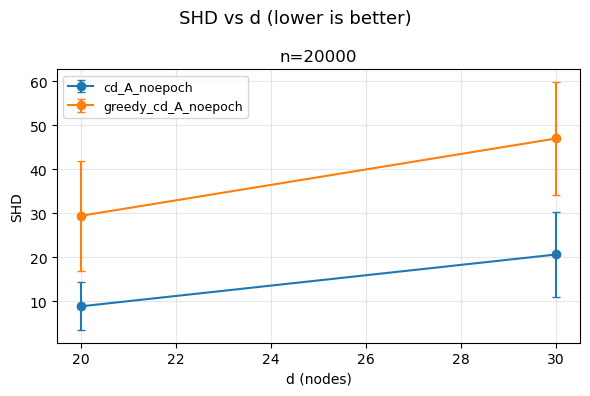

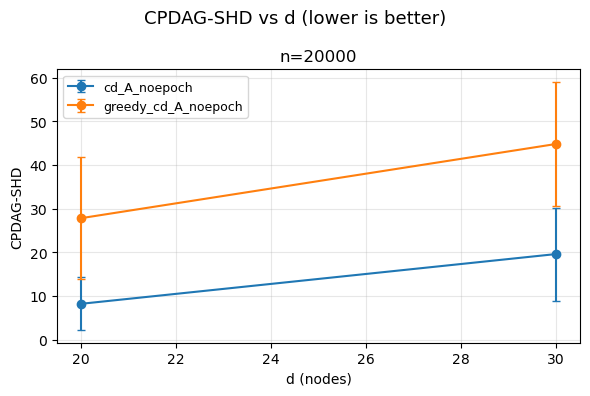

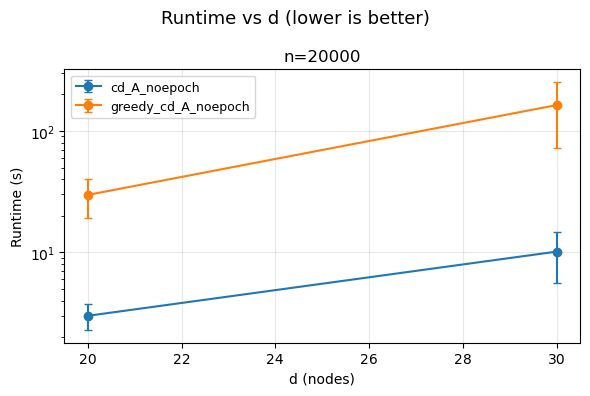

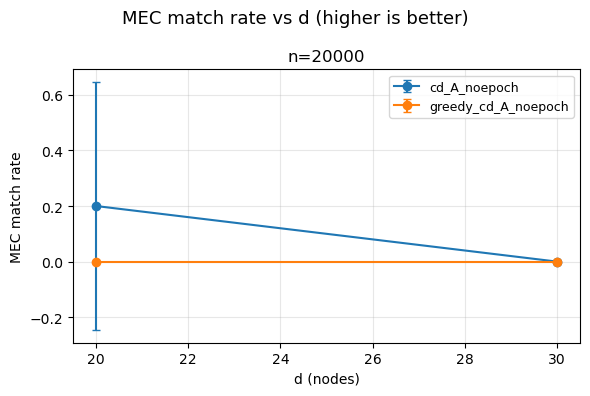

In [8]:
# 7) Plots: SHD and runtime vs d for both algorithms
if len(df_trials) == 0:
    print('Run the previous cell first.')
else:
    n_vals = sorted(df_trials['n_samples'].unique())
    algs = sorted(df_trials['algorithm'].unique())
    color_map = {alg: f'C{i}' for i, alg in enumerate(algs)}

    for metric, ylabel, title, log_y in [
        ('shd', 'SHD', 'SHD vs d (lower is better)', False),
        ('cpdag_shd', 'CPDAG-SHD', 'CPDAG-SHD vs d (lower is better)', False),
        ('runtime_sec', 'Runtime (s)', 'Runtime vs d (lower is better)', True),
        ('mec_match', 'MEC match rate', 'MEC match rate vs d (higher is better)', False),
    ]:
        fig, axes = plt.subplots(1, len(n_vals), figsize=(6 * len(n_vals), 4), sharey=True, squeeze=False)
        for ci, n in enumerate(n_vals):
            ax = axes[0][ci]
            sub = df_trials[df_trials['n_samples'] == n]
            agg = sub.groupby(['d', 'algorithm'])[metric].agg(['mean', 'std']).reset_index()
            for alg in algs:
                vals = agg[agg['algorithm'] == alg].sort_values('d')
                ax.errorbar(
                    vals['d'], vals['mean'], yerr=vals['std'].fillna(0.0),
                    marker='o', capsize=3, label=alg, color=color_map[alg],
                )
            ax.set_title(f'n={n}')
            ax.set_xlabel('d (nodes)')
            if ci == 0:
                ax.set_ylabel(ylabel)
            if log_y:
                ax.set_yscale('log')
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=9, loc='best')
        fig.suptitle(title, fontsize=13)
        plt.tight_layout()
        plt.show()

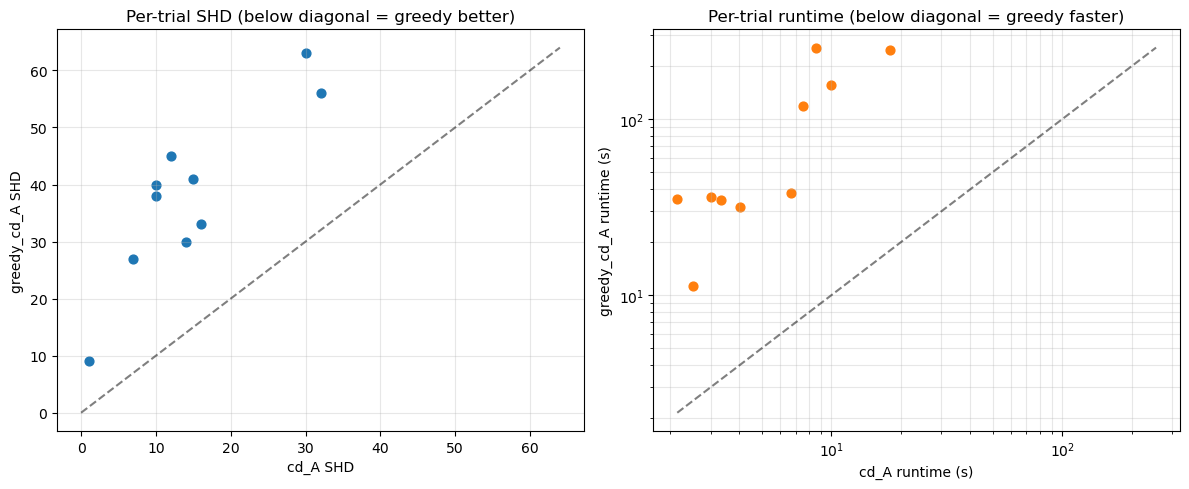

In [9]:
# 8) Per-trial scatter: SHD and runtime, paired by trial
if len(df_trials) == 0:
    print('Run the previous cell first.')
else:
    pivot_shd = df_trials.pivot_table(
        index=['d', 'n_samples', 'trial_id'],
        columns='algorithm',
        values='shd',
    ).reset_index()
    pivot_rt = df_trials.pivot_table(
        index=['d', 'n_samples', 'trial_id'],
        columns='algorithm',
        values='runtime_sec',
    ).reset_index()

    if 'cd_A_noepoch' in pivot_shd.columns and 'greedy_cd_A_noepoch' in pivot_shd.columns:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        ax = axes[0]
        ax.scatter(pivot_shd['cd_A_noepoch'], pivot_shd['greedy_cd_A_noepoch'], c='C0', s=40)
        lim = max(pivot_shd['cd_A_noepoch'].max(), pivot_shd['greedy_cd_A_noepoch'].max()) + 1
        ax.plot([0, lim], [0, lim], 'k--', alpha=0.5)
        ax.set_xlabel('cd_A SHD')
        ax.set_ylabel('greedy_cd_A SHD')
        ax.set_title('Per-trial SHD (below diagonal = greedy better)')
        ax.grid(True, alpha=0.3)

        ax = axes[1]
        ax.scatter(pivot_rt['cd_A_noepoch'], pivot_rt['greedy_cd_A_noepoch'], c='C1', s=40)
        ax.plot(
            [pivot_rt[['cd_A_noepoch', 'greedy_cd_A_noepoch']].min().min(),
             pivot_rt[['cd_A_noepoch', 'greedy_cd_A_noepoch']].max().max()],
            [pivot_rt[['cd_A_noepoch', 'greedy_cd_A_noepoch']].min().min(),
             pivot_rt[['cd_A_noepoch', 'greedy_cd_A_noepoch']].max().max()],
            'k--', alpha=0.5,
        )
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('cd_A runtime (s)')
        ax.set_ylabel('greedy_cd_A runtime (s)')
        ax.set_title('Per-trial runtime (below diagonal = greedy faster)')
        ax.grid(True, alpha=0.3, which='both')

        plt.tight_layout()
        plt.show()
    else:
        print('Need both algorithms present to draw paired plots.')

In [ ]:
# 9) Skip log
if skip_logs:
    display(pd.DataFrame(skip_logs))
else:
    print('No skips.')

No skips.


: 